# iscc — pipeline walkthrough

`iscc` simulates the whole journey from tumor biology to observed molecular data as **three composable stages**:

| Stage | CLI | Produces |
|---|---|---|
| 1. Growth | `isccsim` | a tumor's ground-truth per-cell state |
| 2. Sampling | `isccsample` | a biopsy / dissociation (subset of cells) |
| 3. Assay | `isccdata` | observed sequencing / spatial data |

This notebook runs all three with the **Python API** (and shows the equivalent CLI at the end). For deeper dives see `02_tumor_growth.ipynb` (explore the tumor) and `03_data_overview.ipynb` (explore the data). On-disk formats are documented in `../SCHEMA.md`.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iscc

NB_DIR = os.getcwd()
CONFIG = os.path.join(NB_DIR, "example_config.yaml")
print("iscc from:", iscc.__file__)

iscc from: /Users/pedroferreira/projects/iscc/repo/src/iscc/__init__.py


## Stage 1 — grow a tumor

We build a spatial `GenotypeTumor` from a YAML config and grow it. The config sets the spatial mode, genome size, the CINner-style selection parameters, and per-cell-type rates.

In [2]:
from iscc.tumor.models import GenotypeTumor

tumor = GenotypeTumor(config=CONFIG, seed=2)
tumor.grow(n_steps=300, seed=2)
print(f"Tumor size: {tumor.get_tumor_size()} cells across {len(tumor.demes)} demes")

Tumor size: 888 cells across 625 demes


### Visualise growth and spatial structure

The Muller plot shows clonal dynamics over time; the grid shows where clones and normal cells sit in space.

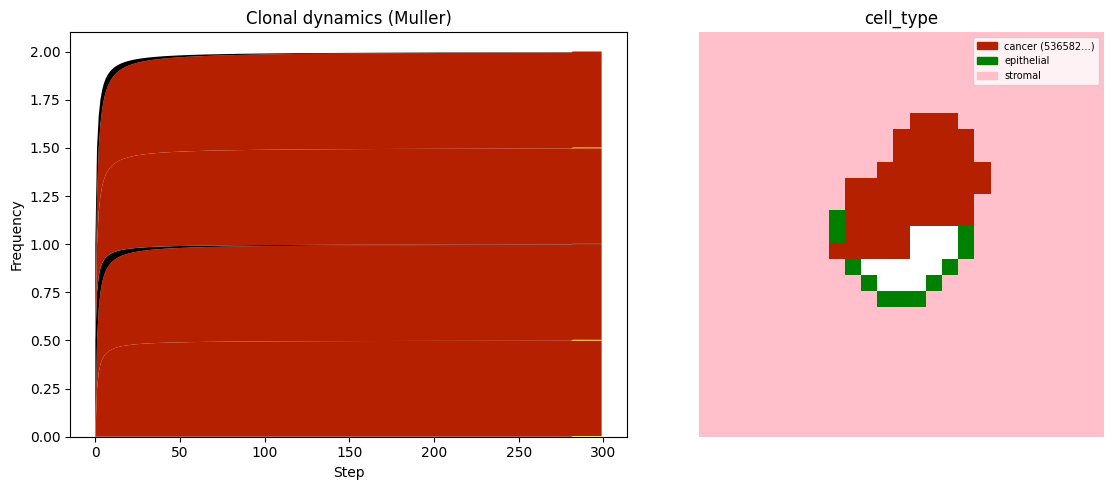

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tumor.plot_muller(ax=axes[0])
axes[0].set_title("Clonal dynamics (Muller)")
tumor.plot_grid(ax=axes[1])
plt.tight_layout()

### The ground truth

The per-cell ground truth lives in `tumor.cell_data` (a dict of DataFrames, also written to `cell_data/` by `tumor.write(path)`). These matrices are what later stages sample and sequence.

In [4]:
cd = tumor.cell_data
print("cell_data matrices:", list(cd.keys()))
cd["cell_snv"].iloc[:5, :6]

cell_data matrices: ['cell_evo', 'cell_snv', 'cell_cnv', 'cell_exp', 'cell_crd', 'cell_type', 'cell_deme']


,G_0_0,G_0_1,G_0_2,G_0_3,G_0_4,G_0_5
C0,0.0,0.0,0.0,0.0,0.0,0.0
C1,0.0,0.0,0.0,0.0,0.0,0.0
C2,0.0,0.0,0.0,0.0,0.0,0.0
C3,0.0,0.0,0.0,0.0,0.0,0.0
C4,0.0,0.0,0.0,0.0,0.0,0.0


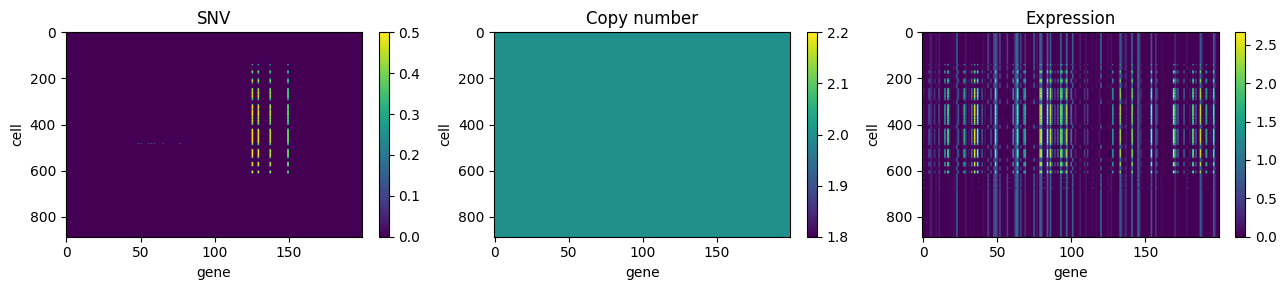

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, key, title in zip(axes, ["cell_snv", "cell_cnv", "cell_exp"], ["SNV", "Copy number", "Expression"]):
    im = ax.imshow(cd[key].values, aspect="auto", cmap="viridis")
    ax.set_title(title); ax.set_xlabel("gene"); ax.set_ylabel("cell")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

## Stage 2 — sample the tumor (biopsy)

`isccsample` captures a subset of cells, preserving their ground truth. Here we take 50% at random (the CLI does the same; spatially-realistic biopsy is on the roadmap).

In [6]:
rng = np.random.default_rng(0)
ids = cd["cell_snv"].index
chosen = rng.choice(np.asarray(ids), size=len(ids) // 2, replace=False)
sample = {k: df.loc[chosen] for k, df in cd.items()}
print(f"Sampled {len(chosen)} / {len(ids)} cells")

Sampled 444 / 888 cells


## Stage 3 — run molecular assays

Each assay turns the sampled cells' ground truth into observed data. The assays live in `iscc.data`.

In [7]:
from iscc.data import scRNA, bulkDNA

sc_assay = scRNA(n_reads=3000, n_cells=300)
sc_assay.run(sample)
print("scRNA UMI matrix:", sc_assay.observed_counts.shape)
sc_assay.observed_counts.iloc[:5, :6]

scRNA UMI matrix: (300, 200)


,G_0_0,G_0_1,G_0_2,G_0_3,G_0_4,G_0_5
C212,14,0,0,0,15,16
C435,15,0,0,0,13,17
C521,21,0,0,0,15,16
C811,0,0,0,0,0,24
C594,0,0,2,0,0,22


Text(0.5, 1.0, 'Bulk DNA VAF spectrum')

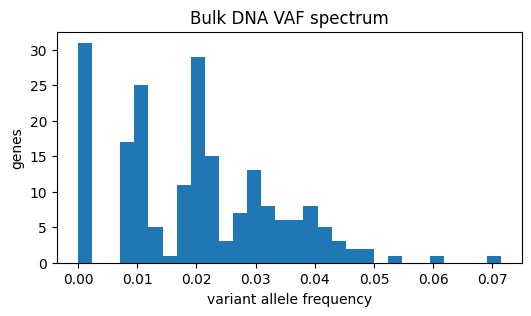

In [8]:
bd = bulkDNA(n_reads=20000, data_mode="counts", fpr=0.02, fnr=0.02)
bd.run(sample)
cov = bd.observed_data["coverage"].replace(0, np.nan)
vaf = (bd.observed_data["alt_counts"] / cov).dropna()
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(vaf, bins=30)
ax.set_xlabel("variant allele frequency"); ax.set_ylabel("genes")
ax.set_title("Bulk DNA VAF spectrum")

## The same pipeline from the command line

```bash
isccsim    --sim-config example_config.yaml -s 300 -o example_out/tumor
isccsample example_out/tumor --method biopsy --fraction 0.5 -o example_out/sample
isccdata   example_out/sample -a scrna --assay-config ../src/iscc/data/assayconfigs/scrna.yaml -o example_out/data_scrna
```

The shared dataset used by the other notebooks is produced once by `generate_example.py`.

**Next:** `02_tumor_growth.ipynb` (the tumor) · `03_data_overview.ipynb` (the data).